<a href="https://colab.research.google.com/github/Divij6/MachineLearningPractice/blob/main/LinearRegression1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Linear Regression + Gradient Descent


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt


Cost Function

In [ ]:
def cost(x, y , w,b ):
  m = x.shape[0]
  cst = 0;
  for i in range(m):
    f_wb = w*x[i] + b
    cst = cst + (f_wb - y[i])**2
  total_cost = (1/(2*m))*cst
  return total_cost

Compute Gradient

In [ ]:
def compute_gradient(x, y, w, b):
  m = x.shape[0]
  dj_dw = 0
  dj_db = 0
  for i in range(m):
    f_wb = w*x[i] + b
    dj_dw_i = (f_wb - y[i])*x[i]
    dj_db_i = f_wb - y[i]
    dj_dw = dj_dw + dj_dw_i
    dj_db = dj_db + dj_db_i
  dj_dw = dj_dw/m
  dj_db = dj_db/m
  return dj_dw, dj_db

Gradient Descent

In [21]:
def compute_gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
  w = w_in
  b = b_in
  J_hist = []
  p_hist = []

  for i in range(num_iters):
    dj_dw, dj_db = gradient_function(x, y, w, b)
    w = w - alpha*dj_dw
    b = b - alpha*dj_db
    if i < 100000:
      J_hist.append(cost_function(x, y, w, b))
      p_hist.append([w, b])
  return w, b, J_hist, p_hist

<a name="toc_40291_2"></a>
# Problem Statement

A house with 1000 square feet sold for \\$300,000 and a house with 2000 square feet sold for \\$500,000.

| Size (1000 sqft)     | Price (1000s of dollars) |
| ----------------| ------------------------ |
| 1               | 300                      |
| 2               | 500                      |


In [22]:
x_train = np.array([1.0, 2.0])           #(size in 1000 square feet)
y_train = np.array([300.0, 500.0])

In [23]:
w_ini = 0
b_ini = 0
iterations = 10000
alpha = 1.0e-2
w_final, b_final, J_history, P_history = compute_gradient_descent(x_train, y_train, w_ini, b_ini, alpha, iterations, cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

(w,b) found by gradient descent: (199.9929,100.0116)


In [16]:
print(f"1000 sqft house prediction {w_final*1.0 + b_final:0.1f} thousand dollars")
print(f"1200 sqft house prediction {w_final*1.2 + b_final:0.1f} thousand dollars")
print(f"2000 sqft house prediction {w_final*2.0 + b_final:0.1f} thousand dollars")

1000 sqft house prediction 300.0 thousand dollars
1200 sqft house prediction 340.0 thousand dollars
2000 sqft house prediction 500.0 thousand dollars


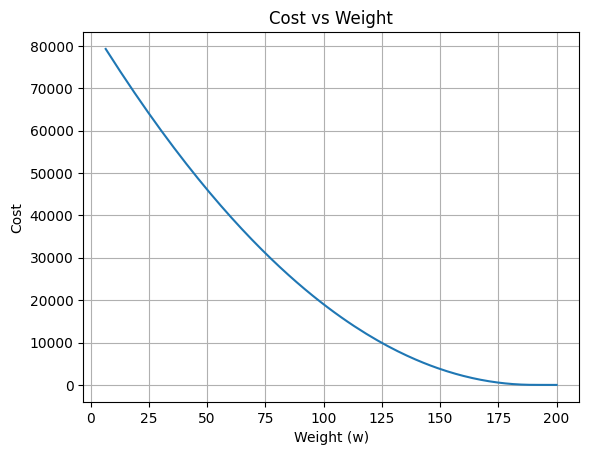

In [25]:
w_history = [p[0] for p in P_history]

plt.plot(w_history, J_history)

plt.xlabel("Weight (w)")
plt.ylabel("Cost")
plt.title("Cost vs Weight")
plt.grid(True)

plt.show()